In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("../dataset/raw/train.csv")
test = pd.read_csv("../dataset/raw/test.csv")

In [3]:
train["TotalSF"] = (
    train["TotalBsmtSF"] +
    train["1stFlrSF"] +
    train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"] +
    test["1stFlrSF"] +
    test["2ndFlrSF"]
)

In [4]:
train["HouseAge"] = (
    train["YrSold"] -
    train["YearBuilt"]
)

test["HouseAge"] = (
    test["YrSold"] -
    test["YearBuilt"]
)

In [5]:
train["RemodelAge"] = (
    train["YrSold"] -
    train["YearRemodAdd"]
)

test["RemodelAge"] = (
    test["YrSold"] -
    test["YearRemodAdd"]
)

In [6]:
train["TotalBath"] = (
    train["FullBath"] +
    (0.5 * train["HalfBath"]) +
    train["BsmtFullBath"] +
    (0.5 * train["BsmtHalfBath"])
)

test["TotalBath"] = (
    test["FullBath"] +
    (0.5 * test["HalfBath"]) +
    test["BsmtFullBath"] +
    (0.5 * test["BsmtHalfBath"])
)

In [7]:
train["TotalPorchSF"] = (
    train["OpenPorchSF"] +
    train["EnclosedPorch"] +
    train["3SsnPorch"] +
    train["ScreenPorch"]
)

test["TotalPorchSF"] = (
    test["OpenPorchSF"] +
    test["EnclosedPorch"] +
    test["3SsnPorch"] +
    test["ScreenPorch"]
)

In [8]:
correlation = train.corr(numeric_only=True)["SalePrice"]

correlation.sort_values(
    ascending=False
)

SalePrice        1.000000
OverallQual      0.790982
TotalSF          0.782260
GrLivArea        0.708624
GarageCars       0.640409
TotalBath        0.631731
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
TotalPorchSF     0.195739
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass  

In [13]:
skewness = train.skew(numeric_only=True)

skewed_columns = skewness[
    skewness.abs() > 0.75
].index

In [14]:
for column in skewed_columns:

    train[column] = np.log1p(train[column])

    test[column] = np.log1p(test[column])

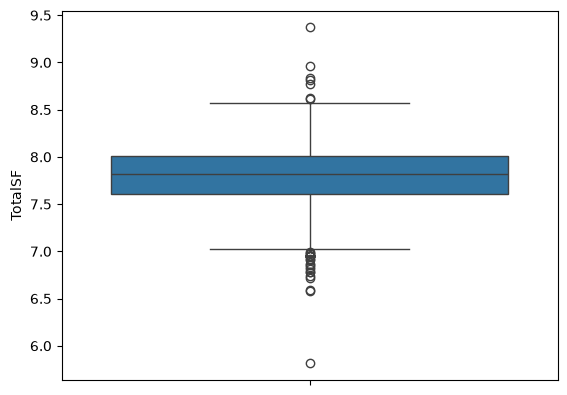

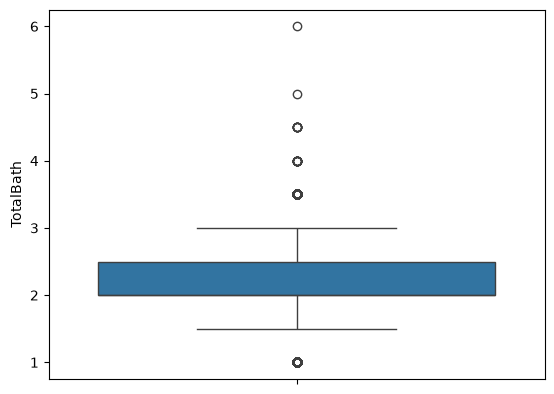

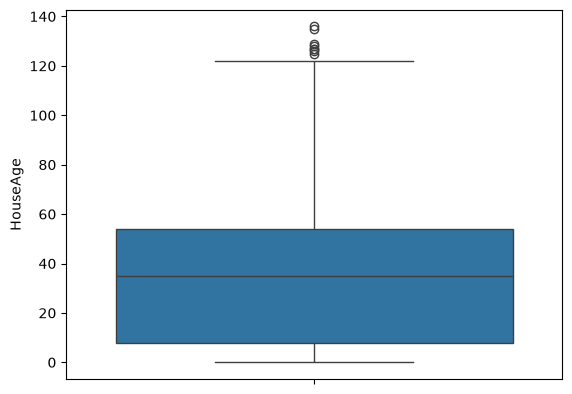

In [16]:
for column in [
    "TotalSF",
    "TotalBath",
    "HouseAge"
]:

    sns.boxplot(y=train[column])

    plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor